## FRAUD DETECTION IN FINANCIAL TRANSACTIONS

## STEP 1: Install & Import All Libraries 

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

from nltk.corpus import stopwords
from nltk.stem   import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection         import train_test_split, cross_val_score
from sklearn.naive_bayes             import MultinomialNB
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.metrics                 import (accuracy_score,
                                             classification_report,
                                             confusion_matrix,
                                             roc_auc_score)
from sklearn.preprocessing           import LabelEncoder

print("✅ STEP 1 DONE: All libraries imported successfully!\n")

✅ STEP 1 DONE: All libraries imported successfully!



## STEP 2: Load & Explore the Dataset

In [ ]:
# We load the CSV file that contains real & fraud transactions.
# Each row has a transaction_description (text) and a label.

In [4]:
df = pd.read_csv("fraud_detection_dataset.csv")

print(" STEP 2 DONE: Dataset loaded!")
print(f"   Rows      : {df.shape[0]}")
print(f"   Columns   : {df.shape[1]}")
print(f"\n   Column Names:\n   {list(df.columns)}")
print(f"\n   Label Distribution:")
print(df['label'].value_counts().to_string())
print(f"\n   Sample Data (first 3 rows):")
print(df[['transaction_description', 'label']].head(3).to_string(index=False))
print()


 STEP 2 DONE: Dataset loaded!
   Rows      : 50
   Columns   : 7

   Column Names:
   ['transaction_id', 'customer_name', 'transaction_description', 'amount', 'location', 'time_of_day', 'label']

   Label Distribution:
label
Legitimate    26
Fraud         24

   Sample Data (first 3 rows):
                                                 transaction_description      label
                Online purchase from Amazon India for laptop accessories Legitimate
                                  ATM withdrawal at SBI branch near home Legitimate
Urgent wire transfer to foreign account immediately click link to verify      Fraud



## STEP 3: Exploratory Data Analysis (EDA)

In [5]:
# EDA means understanding the data visually before building models.
# We check: How long are fraud vs legitimate descriptions?

 STEP 3 DONE: EDA — Text Statistics
            text_length  word_count
label                              
Fraud             70.88       11.50
Legitimate        34.31        4.96



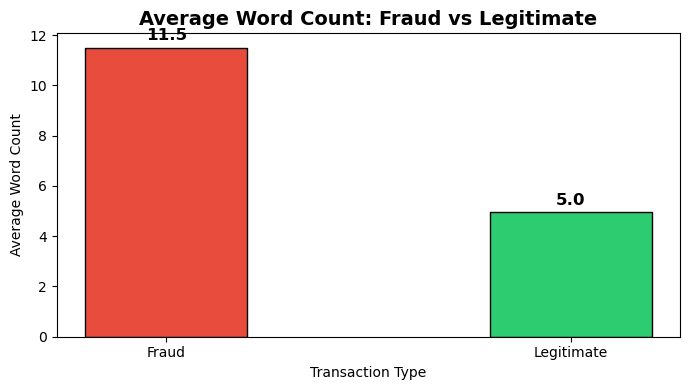

   Chart saved → eda_word_count.png



In [7]:
df['text_length'] = df['transaction_description'].apply(len)
df['word_count']  = df['transaction_description'].apply(lambda x: len(x.split()))
print(" STEP 3 DONE: EDA — Text Statistics")
print(df.groupby('label')[['text_length', 'word_count']].mean().round(2).to_string())
print()

# Bar chart: Average word count per label
avg_words = df.groupby('label')['word_count'].mean()
colors    = ['#e74c3c' if l == 'Fraud' else '#2ecc71' for l in avg_words.index]

plt.figure(figsize=(7, 4))
bars = plt.bar(avg_words.index, avg_words.values, color=colors, edgecolor='black', width=0.4)
for bar, val in zip(bars, avg_words.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
plt.title("Average Word Count: Fraud vs Legitimate", fontsize=14, fontweight='bold')
plt.ylabel("Average Word Count")
plt.xlabel("Transaction Type")
plt.tight_layout()
plt.savefig("eda_word_count.png", dpi=150)
plt.show()
print("   Chart saved → eda_word_count.png\n")

## STEP 4: Text Preprocessing

In [8]:
# Raw text is messy. We CLEAN it before feeding to any model.
#
# Steps inside preprocessing:
#   1. Lowercase          → "URGENT" becomes "urgent"
#   2. Remove symbols     → "click!!" becomes "click"
#   3. Tokenize           → "send money now" → ["send","money","now"]
#   4. Remove stopwords   → remove "the", "is", "your", etc.
#   5. Stemming           → "clicking" → "click", "blocked" → "block"

In [9]:
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

# We keep some fraud-signal words that are normally stopwords
fraud_signals = {'urgent', 'immediately', 'now', 'free', 'win',
                 'click', 'verify', 'blocked', 'suspended', 'claim',
                 'limited', 'offer', 'prize', 'reward', 'lucky'}
stop_words = stop_words - fraud_signals   # Don't remove fraud keywords!

def preprocess_text(text):
    text   = str(text).lower()                     # Step 1: lowercase
    text   = re.sub(r'[^a-zA-Z\s]', '', text)      # Step 2: remove symbols/numbers
    tokens = text.split()                           # Step 3: tokenize
    tokens = [w for w in tokens if w not in stop_words]  # Step 4: stopwords
    tokens = [stemmer.stem(w) for w in tokens]      # Step 5: stemming
    return ' '.join(tokens)

df['cleaned_text'] = df['transaction_description'].apply(preprocess_text)

print(" STEP 4 DONE: Text preprocessing complete!")
print("   Example — BEFORE:", df['transaction_description'][2][:70])
print("   Example — AFTER :", df['cleaned_text'][2][:70])
print()

 STEP 4 DONE: Text preprocessing complete!
   Example — BEFORE: Urgent wire transfer to foreign account immediately click link to veri
   Example — AFTER : urgent wire transfer foreign account immedi click link verifi



## STEP 5: Word Cloud Visualization

In [10]:
# Word clouds show which words appear MOST in each category.
# Fraud texts often have: urgent, verify, click, prize, money, now
# Legitimate texts have: payment, purchase, bill, subscription, booking

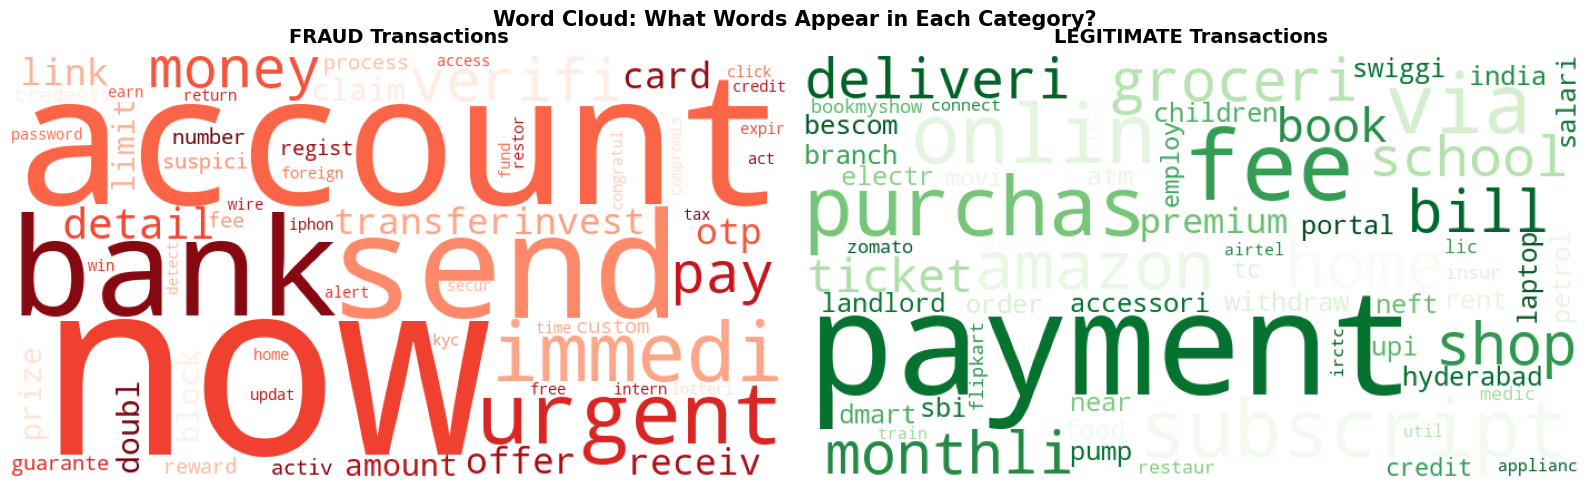

 STEP 5 DONE: Word clouds saved → wordcloud_fraud.png



In [11]:
try:
    from wordcloud import WordCloud

    fraud_text   = ' '.join(df[df['label'] == 'Fraud']['cleaned_text'])
    legit_text   = ' '.join(df[df['label'] == 'Legitimate']['cleaned_text'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    configs = [
        (fraud_text,  "FRAUD Transactions",      "Reds"),
        (legit_text,  "LEGITIMATE Transactions",  "Greens"),
    ]

    for ax, (text, title, cmap) in zip(axes, configs):
        wc = WordCloud(width=700, height=380,
                       background_color='white',
                       colormap=cmap,
                       max_words=60).generate(text)
        ax.imshow(wc)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    plt.suptitle("Word Cloud: What Words Appear in Each Category?",
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig("wordcloud_fraud.png", dpi=150)
    plt.show()
    print(" STEP 5 DONE: Word clouds saved → wordcloud_fraud.png\n")

except ImportError:
    print(" STEP 5 SKIPPED: Run  pip install wordcloud  to see word clouds\n")

## STEP 6: Feature Extraction — TF-IDF

In [13]:
# TF-IDF = Term Frequency × Inverse Document Frequency
#
# WHY TF-IDF?
#   - "urgent" in a fraud message is more meaningful than common words
#   - TF-IDF gives HIGH score to words that are rare but important
#   - It converts text (string) → numbers (vector) for ML models
#
# max_features=300 → use only top 300 most important words
# ngram_range=(1,2) → also capture 2-word phrases like "click link", "verify otp"

In [15]:
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2))

X = tfidf.fit_transform(df['cleaned_text'])   # Feature matrix (numbers)
y = df['label']                                # Labels: Fraud / Legitimate

print(" STEP 6 DONE: TF-IDF Vectorization complete!")
print(f"   Feature matrix shape : {X.shape}  (50 rows × 300 features)")
print(f"   Sample top features  : {list(tfidf.get_feature_names_out()[:12])}")
print()

 STEP 6 DONE: TF-IDF Vectorization complete!
   Feature matrix shape : (50, 300)  (50 rows × 300 features)
   Sample top features  : ['abroad', 'account', 'activ', 'amazon', 'amount', 'bank', 'bank detail', 'bill', 'bill payment', 'block', 'book', 'branch near']



## STEP 7: Encode Labels

In [16]:
# ML models need numbers, not words.
# "Fraud" → 0,  "Legitimate" → 1  (done by LabelEncoder)

In [17]:
le      = LabelEncoder()
y_enc   = le.fit_transform(y)   # Fraud=0, Legitimate=1

print(" STEP 7 DONE: Label encoding complete!")
print(f"   Classes : {list(le.classes_)}  →  [0, 1]")
print()

 STEP 7 DONE: Label encoding complete!
   Classes : ['Fraud', 'Legitimate']  →  [0, 1]



## STEP 8: Train / Test Split

In [18]:
# We split data: 80% for training, 20% for testing.
# The model NEVER sees test data during training — fair evaluation!

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(" STEP 8 DONE: Data split complete!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")
print()

 STEP 8 DONE: Data split complete!
   Training samples : 40
   Testing  samples : 10



## STEP 9: Train Multiple Models & Compare

In [20]:
# We train 3 popular NLP classifiers and compare their accuracy.
#
# 1. Naive Bayes       → Fast, works great for text, based on probability
# 2. Logistic Regression → Powerful linear classifier, widely used in NLP
# 3. SVM (LinearSVC)   → Best margin-based classifier, great for text data

In [22]:
models = {
    "Naive Bayes"         : MultinomialNB(),
    "Logistic Regression" : LogisticRegression(max_iter=1000, C=1.0),
    "SVM (LinearSVC)"     : LinearSVC(max_iter=2000),
}

results = {}
print("STEP 9: Training & Evaluating Models")
print("-" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'CV Score':>10}")
print("-" * 50)

for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds    = clf.predict(X_test)
    acc      = accuracy_score(y_test, preds)
    cv_score = cross_val_score(clf, X, y_enc, cv=5, scoring='accuracy').mean()
    results[name] = {"model": clf, "preds": preds, "accuracy": acc, "cv": cv_score}
    print(f"   {name:<23} {acc*100:>8.1f}%  {cv_score*100:>8.1f}%")

print("-" * 50)
print()

# Pick the best model
best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_preds = results[best_name]['preds']
best_model = results[best_name]['model']

print(f" Best Model: {best_name}")
print()
print(" Detailed Classification Report:")
print(classification_report(y_test, best_preds,
                             target_names=le.classes_))


STEP 9: Training & Evaluating Models
--------------------------------------------------
Model                       Accuracy   CV Score
--------------------------------------------------
   Naive Bayes                 90.0%      96.0%
   Logistic Regression         90.0%      96.0%
   SVM (LinearSVC)            100.0%      98.0%
--------------------------------------------------

 Best Model: SVM (LinearSVC)

 Detailed Classification Report:
              precision    recall  f1-score   support

       Fraud       1.00      1.00      1.00         5
  Legitimate       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## STEP 10: Confusion Matrix

In [23]:
# Shows exactly how many predictions were right/wrong.
#
#              Predicted
#           Fraud | Legit
# Actual Fraud [TP | FN]   ← TP = correctly caught fraud
# Actual Legit [FP | TN]   ← FP = false alarm (legit flagged as fraud)
#
# Goal: Maximize TP, Minimize FN (missing real fraud is dangerous!)

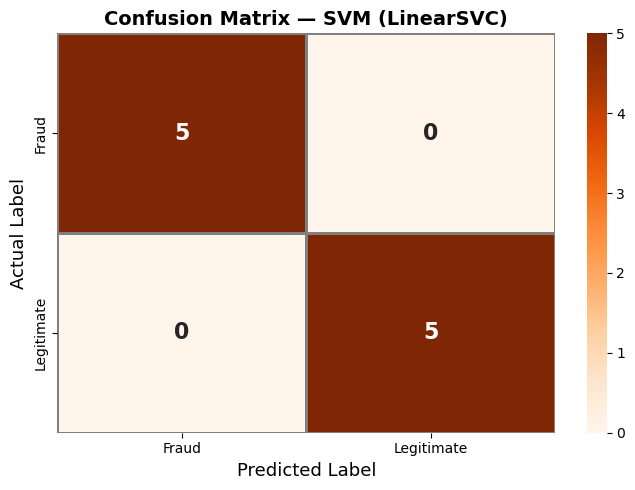

STEP 10 DONE: Confusion matrix saved → confusion_matrix_fraud.png



In [25]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=2, linecolor='gray',
            annot_kws={"size": 16, "weight": "bold"})
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("Actual Label",    fontsize=13)
plt.title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_fraud.png", dpi=150)
plt.show()
print("STEP 10 DONE: Confusion matrix saved → confusion_matrix_fraud.png\n")

## STEP 11: Model Accuracy Bar Chart

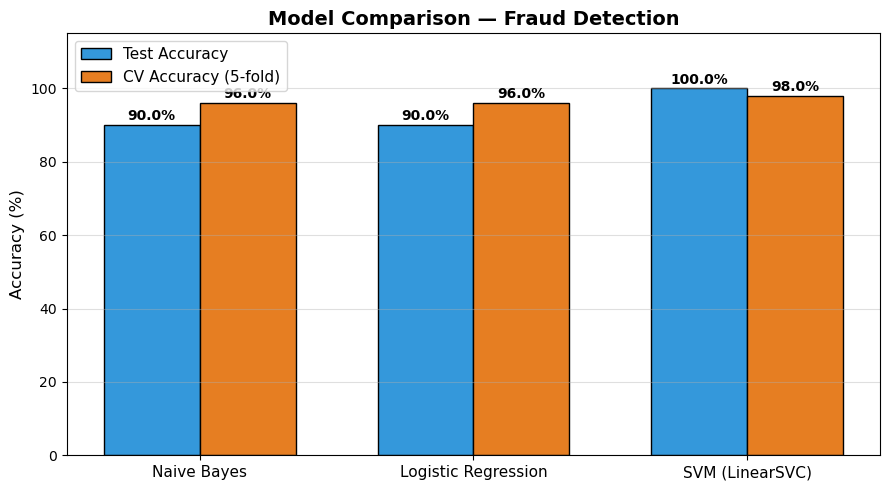

✅ STEP 11 DONE: Model comparison chart saved → model_comparison_fraud.png



In [26]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
cv_scores   = [results[m]['cv'] * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy',
               color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_scores,  width, label='CV Accuracy (5-fold)',
               color='#e67e22', edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison — Fraud Detection", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("model_comparison_fraud.png", dpi=150)
plt.show()
print(" STEP 11 DONE: Model comparison chart saved → model_comparison_fraud.png\n")

## STEP 12: Top Fraud Keywords (Feature Importance)

In [27]:
# Which words does the model think are MOST FRAUD-LIKE?
# This gives us insight into what makes a message look suspicious.

C:\Users\Dell\AppData\Local\Temp\ipykernel_3112\2675792522.py:26: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_3112\2675792522.py:27: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig("top_keywords_fraud.png", dpi=150)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


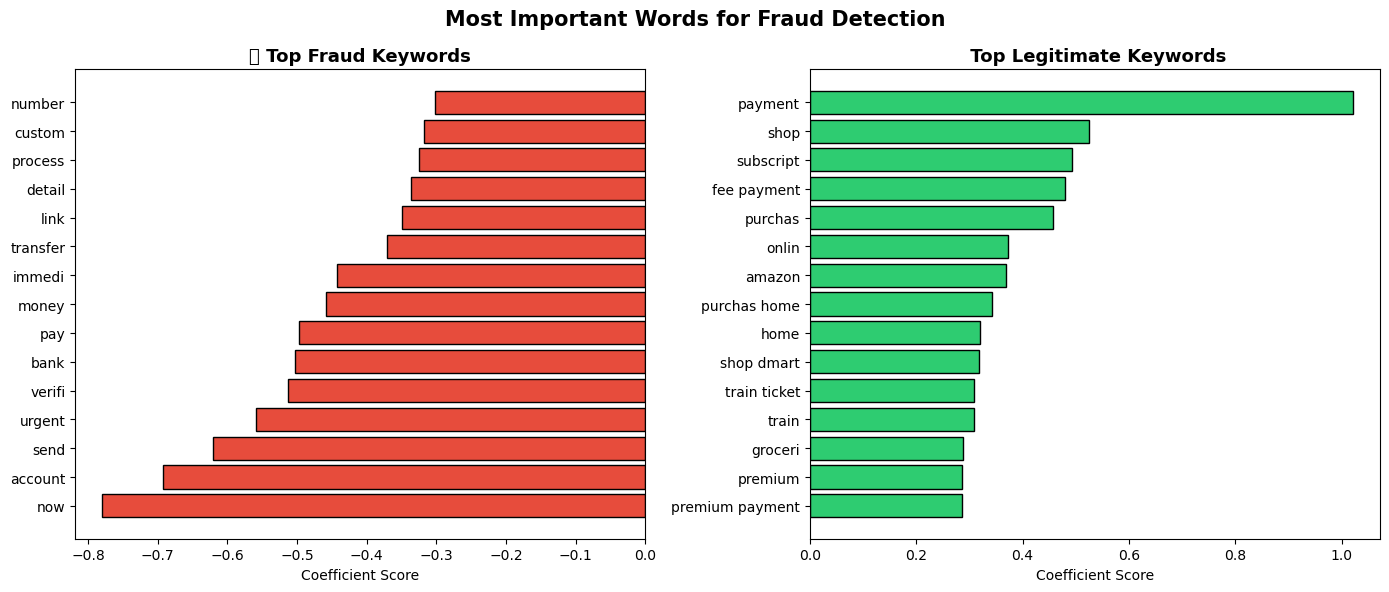

STEP 12 DONE: Feature importance chart saved → top_keywords_fraud.png



In [28]:
if hasattr(best_model, 'coef_'):
    feature_names = tfidf.get_feature_names_out()
    coefs         = best_model.coef_[0]

    # Top fraud words (most negative = most "Fraud" leaning for class 0)
    top_fraud_idx  = np.argsort(coefs)[:15]
    top_legit_idx  = np.argsort(coefs)[-15:]

    fraud_words  = [feature_names[i] for i in top_fraud_idx]
    legit_words  = [feature_names[i] for i in top_legit_idx]
    fraud_scores = [coefs[i] for i in top_fraud_idx]
    legit_scores = [coefs[i] for i in top_legit_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].barh(fraud_words, fraud_scores, color='#e74c3c', edgecolor='black')
    axes[0].set_title("🚨 Top Fraud Keywords", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Coefficient Score")

    axes[1].barh(legit_words, legit_scores, color='#2ecc71', edgecolor='black')
    axes[1].set_title(" Top Legitimate Keywords", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Coefficient Score")

    plt.suptitle("Most Important Words for Fraud Detection",
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig("top_keywords_fraud.png", dpi=150)
    plt.show()
    print("STEP 12 DONE: Feature importance chart saved → top_keywords_fraud.png\n")

## STEP 13: Predict on New Transactions

In [29]:
# Test your trained model on brand new transaction descriptions!
# Try changing these texts to see what the model predicts.

In [31]:
print("=" * 60)
print("✅ STEP 13: Predicting on New Transaction Descriptions")
print("=" * 60)

new_transactions = [
    "Urgent! Your SBI account is blocked. Click link and enter OTP immediately to restore.",
    "Paid electricity bill via BESCOM online portal",
    "You have won 10 lakh rupees in KBC lottery send bank details to claim prize now",
    "Monthly EMI payment for home loan deducted from account",
    "Dear customer verify your Aadhaar card linked bank account to avoid suspension",
    "Booked railway tickets for family vacation on IRCTC",
]

print(f"\n{'#':<4} {'Description':<55} {'Prediction'}")
print("-" * 80)

for i, text in enumerate(new_transactions, 1):
    cleaned    = preprocess_text(text)
    vectorized = tfidf.transform([cleaned])
    pred_enc   = best_model.predict(vectorized)[0]
    prediction = le.inverse_transform([pred_enc])[0]
    icon       = " FRAUD      " if prediction == 'Fraud' else " LEGITIMATE"
    short_text = text[:53] + '..' if len(text) > 53 else text
    print(f"{i:<4} {short_text:<55} {icon}")

print()
print("=" * 60)
print("🎉 PROJECT COMPLETE! All 13 steps ran successfully.")

✅ STEP 13: Predicting on New Transaction Descriptions

#    Description                                             Prediction
--------------------------------------------------------------------------------
1    Urgent! Your SBI account is blocked. Click link and e..  FRAUD      
2    Paid electricity bill via BESCOM online portal           LEGITIMATE
3    You have won 10 lakh rupees in KBC lottery send bank ..  FRAUD      
4    Monthly EMI payment for home loan deducted from accou..  LEGITIMATE
5    Dear customer verify your Aadhaar card linked bank ac..  FRAUD      
6    Booked railway tickets for family vacation on IRCTC      LEGITIMATE

🎉 PROJECT COMPLETE! All 13 steps ran successfully.


In [32]:
print("=" * 60)
print()
print("📁 Output Files Generated:")
print("   • eda_word_count.png         — Word count comparison chart")
print("   • wordcloud_fraud.png        — Word clouds (fraud vs legitimate)")
print("   • confusion_matrix_fraud.png — Confusion matrix")
print("   • model_comparison_fraud.png — Accuracy comparison of 3 models")
print("   • top_keywords_fraud.png     — Most important fraud keywords")


📁 Output Files Generated:
   • eda_word_count.png         — Word count comparison chart
   • wordcloud_fraud.png        — Word clouds (fraud vs legitimate)
   • confusion_matrix_fraud.png — Confusion matrix
   • model_comparison_fraud.png — Accuracy comparison of 3 models
   • top_keywords_fraud.png     — Most important fraud keywords
